# SMURF-lite：Human Breast Cancer FFPE（Visium HD）复现


## 0. 首次安装环境（只在 Terminal 中执行一次）

```bash
conda create -n smurf-breast python=3.10 -y
conda activate smurf-breast
python -m pip install --upgrade pip
python -m pip install pysmurf jupyterlab ipykernel
python -m ipykernel install --user --name smurf-breast --display-name "Python (smurf-breast)"
```

StarDist 建议单独安装并先测试：

```bash
conda activate smurf-breast
python -m pip install stardist csbdeep tensorflow
```

之后启动：`jupyter lab`，打开本 notebook，并选择 `Python (smurf-breast)` 内核。

## 1. 导入依赖

In [1]:
from pathlib import Path
import copy
import gzip
import json
import pickle
import shutil
import tarfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import smurf as su

print("SMURF:", su.__version__)
print("Scanpy:", sc.__version__)

SMURF: 3.0.1
Scanpy: 1.11.5


/var/folders/m4/bs6lxq1j1332zyrwflcjg1980000gn/T/ipykernel_36094/3373748614.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## 2. 设置数据与结果路径

In [10]:
DATA_ROOT = Path("/Volumes/My Passport/Data")
BIN_ARCHIVE = DATA_ROOT / "Visium_HD_Human_Breast_Cancer_FFPE_binned_outputs.tar.gz"
SPATIAL_ARCHIVE = DATA_ROOT / "Visium_HD_Human_Breast_Cancer_FFPE_spatial.tar.gz"


WORK_ROOT = DATA_ROOT / "SMURF_Human_Breast_Cancer_FFPE"
EXTRACT_ROOT = WORK_ROOT / "input"
RESULTS = WORK_ROOT / "results_lite"
TILES = WORK_ROOT / "stardist_tiles"

for p in (WORK_ROOT, EXTRACT_ROOT, RESULTS, TILES):
    p.mkdir(parents=True, exist_ok=True)

assert DATA_ROOT.exists(), f"外置盘路径不存在：{DATA_ROOT}"
assert BIN_ARCHIVE.exists(), f"找不到：{BIN_ARCHIVE}"
print("工作目录:", WORK_ROOT)
print("外置盘剩余空间:", shutil.disk_usage(DATA_ROOT).free / 1024**3, "GiB")

工作目录: /Volumes/My Passport/Data/SMURF_Human_Breast_Cancer_FFPE
外置盘剩余空间: 845.857421875 GiB


In [11]:
def safe_extract_tar_gz(archive: Path, destination: Path):
    marker = destination / ("." + archive.name + ".extracted")
    if marker.exists():
        print("已解压，跳过:", archive.name)
        return
    print("开始解压:", archive)
    with tarfile.open(archive, "r:gz") as tf:
        root = destination.resolve()
        for member in tf.getmembers():
            target = (destination / member.name).resolve()
            if root not in target.parents and target != root:
                raise RuntimeError(f"压缩包包含不安全路径: {member.name}")
        tf.extractall(destination)
    marker.touch()
    print("解压完成:", archive.name)

safe_extract_tar_gz(BIN_ARCHIVE, EXTRACT_ROOT)
safe_extract_tar_gz(SPATIAL_ARCHIVE, EXTRACT_ROOT)

已解压，跳过: Visium_HD_Human_Breast_Cancer_FFPE_binned_outputs.tar.gz
已解压，跳过: Visium_HD_Human_Breast_Cancer_FFPE_spatial.tar.gz


## 4. 自动定位 2 µm 矩阵、spot 坐标与全分辨率 H&E 图像

In [13]:
BIN_2UM = EXTRACT_ROOT / "binned_outputs" / "square_002um"
MATRIX_DIR = BIN_2UM / "filtered_feature_bc_matrix"
POSITIONS = BIN_2UM / "spatial" / "tissue_positions.parquet"

image_candidates = [
    BIN_2UM / "spatial" / "aligned_tissue_image.jpg",
    EXTRACT_ROOT / "spatial" / "aligned_tissue_image.jpg",
    BIN_2UM / "spatial" / "cytassist_image.tiff",
    EXTRACT_ROOT / "spatial" / "cytassist_image.tiff",
]
IMAGE = next((p for p in image_candidates if p.exists()), None)

assert MATRIX_DIR.exists(), MATRIX_DIR
assert POSITIONS.exists(), POSITIONS
assert IMAGE is not None, "没有找到全分辨率 aligned_tissue_image.jpg/cytassist_image.tiff"

print("matrix:", MATRIX_DIR)
print("positions:", POSITIONS)
print("image:", IMAGE)

matrix: /Volumes/My Passport/Data/SMURF_Human_Breast_Cancer_FFPE/input/binned_outputs/square_002um/filtered_feature_bc_matrix
positions: /Volumes/My Passport/Data/SMURF_Human_Breast_Cancer_FFPE/input/binned_outputs/square_002um/spatial/tissue_positions.parquet
image: /Volumes/My Passport/Data/SMURF_Human_Breast_Cancer_FFPE/input/binned_outputs/square_002um/spatial/aligned_tissue_image.jpg


## 5. 检查 spot 表和图像

这里先检查坐标范围。官方 SMURF 对 Visium HD 2 µm 数据默认使用 `row_number=3350, col_number=3350`；保留该设置以对齐官方教程。

In [19]:
positions = pd.read_parquet(POSITIONS)
display(positions.head())
print("rows:", positions["array_row"].min(), "→", positions["array_row"].max())
print("cols:", positions["array_col"].min(), "→", positions["array_col"].max())
print("in-tissue spots:", int(positions["in_tissue"].sum()))

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,s_002um_00000_00000-1,1,0,0,1265.919531,21565.433889
1,s_002um_00000_00001-1,1,0,1,1266.036747,21559.280704
2,s_002um_00000_00002-1,1,0,2,1266.153963,21553.127519
3,s_002um_00000_00003-1,1,0,3,1266.271178,21546.974334
4,s_002um_00000_00004-1,1,0,4,1266.388394,21540.821149


rows: 0 → 3349
cols: 0 → 3349
in-tissue spots: 10535119


In [22]:
so = su.prepare_dataframe_image(
    str(POSITIONS),
    str(IMAGE),
    image_format="HE",
    row_number=3350,
    col_number=3350,
) 
print("shape:", so.image_temp().shape)
print("spot mask shape:", so.pixels.shape)

shape: (4622, 5044, 3)
spot mask shape: (4622, 5044)


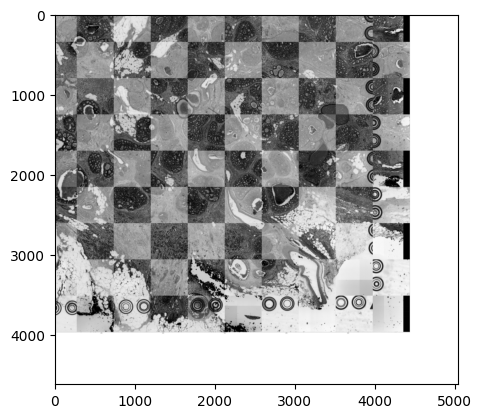

In [23]:
plt.imshow(so.image_temp())
plt.show()
plt.close()

## 8. 保存待分割图像

In [24]:
SEGMENTATION_INPUT = WORK_ROOT / "image_to_segmentation.npy.gz"
if not SEGMENTATION_INPUT.exists():
    with gzip.GzipFile(SEGMENTATION_INPUT, "w") as f:
        np.save(f, so.image_temp())
    print("已保存:", SEGMENTATION_INPUT)
else:
    print("已存在，跳过:", SEGMENTATION_INPUT)

已存在，跳过: /Volumes/My Passport/Data/SMURF_Human_Breast_Cancer_FFPE/image_to_segmentation.npy.gz


## 9. StarDist 小块试跑（必须先人工检查）

官方使用预训练 `2D_versatile_he`。先测试图像中心附近一个 2048×2048 区域。若明显漏检，逐步降低 `PROB_THRESH`；若背景假阳性很多，则升高它。

In [17]:
from csbdeep.utils import normalize
from stardist.models import StarDist2D

model = StarDist2D.from_pretrained("2D_versatile_he")
image = so.image_temp()
h, w = image.shape[:2]
test_size = 2048
r0 = max(0, h // 2 - test_size // 2)
c0 = max(0, w // 2 - test_size // 2)
test_img = image[r0:r0+test_size, c0:c0+test_size]

PROB_THRESH = 0.01
test_norm = normalize(test_img, 1, 99.8, axis=(0, 1, 2))
test_labels, _ = model.predict_instances(test_norm, prob_thresh=PROB_THRESH)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(test_img); ax[0].set_title("H&E test tile"); ax[0].axis("off")
ax[1].imshow(test_img); ax[1].imshow(test_labels, alpha=0.45, cmap="turbo")
ax[1].set_title(f"StarDist overlay; nuclei={test_labels.max()}"); ax[1].axis("off")
plt.show()

ModuleNotFoundError: No module named 'csbdeep'

## 10. 分块运行整张图

官方教程使用 `loop=4700`、`gap=80`。每个 tile 单独写盘，因此内核中断后可继续。这个步骤通常最耗时。

In [18]:
LOOP = 4700
GAP = 80
i_max, j_max = image.shape[:2]

for i in range(0, i_max, LOOP):
    for j in range(0, j_max, LOOP):
        tile_file = TILES / f"tile_{i}_{j}.npy"
        if tile_file.exists():
            print("skip", tile_file.name)
            continue
        tile = image[max(0, i-GAP):min(i+LOOP, i_max), max(0, j-GAP):min(j+LOOP, j_max)]
        tile_norm = normalize(tile, 1, 99.8, axis=(0, 1, 2))
        labels, _ = model.predict_instances(tile_norm, prob_thresh=PROB_THRESH)
        np.save(tile_file, labels.astype(np.int32))
        print("saved", tile_file.name, "shape=", labels.shape, "nuclei=", labels.max())

NameError: name 'image' is not defined

## 11. 合并分块结果，保存最终核标签 mask

In [ ]:
segmentation_results = {}
for i in range(0, i_max, LOOP):
    for j in range(0, j_max, LOOP):
        tile_file = TILES / f"tile_{i}_{j}.npy"
        assert tile_file.exists(), f"缺少 tile: {tile_file}"
        segmentation_results[(i, j)] = np.load(tile_file, mmap_mode="r")

so.add_segmentation(segmentation_results, i_max, j_max, LOOP, GAP)
so.segmentation_final = so.segmentation_final.astype(np.int32)
SEGMENTATION_FINAL = WORK_ROOT / "segmentation_final.npy"
np.save(SEGMENTATION_FINAL, so.segmentation_final)
print("保存:", SEGMENTATION_FINAL)
print("mask shape:", so.segmentation_final.shape, "labels:", int(so.segmentation_final.max()))

## 12. 重启后从 mask 恢复（若刚完成上一步，可直接运行）

这一单元格确保后续总是从磁盘上的最终 mask 开始。

In [ ]:
SEGMENTATION_FINAL = WORK_ROOT / "segmentation_final.npy"
assert SEGMENTATION_FINAL.exists(), "请先完成 StarDist 分割，或把自己的标签 mask 保存到该路径"
so.segmentation_final = np.load(SEGMENTATION_FINAL, mmap_mode="r")
assert so.segmentation_final.shape == so.image_temp().shape[:2]
assert np.issubdtype(so.segmentation_final.dtype, np.integer)
print("mask OK:", so.segmentation_final.shape, so.segmentation_final.dtype)

## 13. 分割质量快速检查

In [ ]:
stride = max(1, int(max(so.image_temp().shape[:2]) / 2500))
img_small = so.image_temp()[::stride, ::stride]
mask_small = np.asarray(so.segmentation_final[::stride, ::stride])
plt.figure(figsize=(14, 14))
plt.imshow(img_small)
plt.imshow(np.ma.masked_equal(mask_small, 0), cmap="turbo", alpha=0.40, interpolation="nearest")
plt.title("Nuclei segmentation overlay")
plt.axis("off")
plt.show()

## 14. 生成 cell–spot 空间关系

In [ ]:
so.generate_cell_spots_information(max_spot=50, cells_main_pct=1/6)
print("保留的 nuclei:", len(so.cells_main))

## 15. 读取 2 µm 表达矩阵，并严格按 tissue barcode 对齐

In [ ]:
adata = sc.read_10x_mtx(str(MATRIX_DIR), var_names="gene_symbols", make_unique=True)
tissue_barcodes = so.df.loc[so.df["in_tissue"] == 1, "barcode"].astype(str)
missing = tissue_barcodes.difference(adata.obs_names)
assert len(missing) == 0, f"表达矩阵缺少 {len(missing)} 个 tissue barcodes"
adata = adata[tissue_barcodes].copy()
print(adata)

## 16. 过滤极低总 counts 的基因

沿用官方教程的 `min_counts=1000`。乳腺癌样本若保留下来的基因过少，可将阈值降到 100–500。

In [ ]:
print("过滤前 genes:", adata.n_vars)
sc.pp.filter_genes(adata, min_counts=1000)
print("过滤后 genes:", adata.n_vars)
assert adata.n_vars >= 1000, "保留基因过少，请降低 min_counts 后重新运行"

## 17. 聚合核心 spot，生成 nuclei × genes 矩阵

In [ ]:
su.nuclei_rna(adata, so)
adata_sc = so.final_nuclei.copy()
sc.pp.filter_cells(adata_sc, min_counts=5)
adata_raw = adata_sc.copy()
print(adata_sc)

## 18. 初始 Scanpy 聚类

SMURF 官方默认 Leiden `resolution=2`。这是算法 cluster，不是最终人工注释的细胞类型。

In [ ]:
adata_sc = su.singlecellanalysis(
    adata_sc,
    resolution=2,
    regress_out=True,
    random_state=0,
    show=True,
)
print(adata_sc.obs["leiden"].value_counts().sort_index())

## 19. 迭代细胞区域扩张与重新聚类（耗时步骤）

In [ ]:
su.itering_arragement(
    adata_sc,
    adata_raw,
    adata,
    so,
    resolution=2,
    save_folder=str(RESULTS) + "/",
    show=True,
    keep_previous=False,
    max_distance=2,
    allow_equal=False,
    max_iter=30,
    stop_iter=2,
)

## 20. 读取迭代产生的最佳结果

In [ ]:
adatas_final = sc.read_h5ad(RESULTS / "adatas.h5ad")
with open(RESULTS / "cells_final.pkl", "rb") as f:
    cells_final = pickle.load(f)
with open(RESULTS / "weights_record.pkl", "rb") as f:
    weights_record = pickle.load(f)
print(adatas_final)
print("cells_final:", len(cells_final))

## 21. 查看 cluster 的空间分布

In [ ]:
cell_cluster_final = su.return_celltype_plot(adatas_final, so)
su.plot_cellcluster_position(cell_cluster_final, col_num=5)

## 22. SMURF-lite：把共享 spot 的 counts 分配到细胞

In [ ]:
adata_sc_final = su.get_finaldata_fast(
    cells_final,
    so,
    adatas_final,
    adata,
    weights_record,
    plot=True,
)
print(adata_sc_final)

## 23. 保存核心结果

In [ ]:
with open(RESULTS / "so.pkl", "wb") as f:
    pickle.dump(so, f)
adata_sc_final.write(RESULTS / "adata_sc_final_filtered_genes.h5ad")
print("已保存:", RESULTS / "adata_sc_final_filtered_genes.h5ad")

## 24. 使用完整基因集重建最终 cell × gene 矩阵

In [ ]:
adata_full = sc.read_10x_mtx(str(MATRIX_DIR), var_names="gene_symbols", make_unique=True)
adata_full = adata_full[tissue_barcodes].copy()
weight_full = su.calculate_weight_to_celltype(adatas_final, adata_full, cells_final, so)
adata_sc_final_full = su.get_finaldata_fast(
    cells_final,
    so,
    adatas_final,
    adata_full,
    weight_full,
    plot=False,
)
adata_sc_final_full.write(RESULTS / "adata_sc_final_all_genes.h5ad")
print(adata_sc_final_full)

## 25. 保存空间叠加图

In [ ]:
su.plot_results(
    so.image_temp(),
    so.pixels_cells,
    dpi=600,
    save=str(RESULTS / "final_results.pdf"),
)
print("全部完成。结果目录:", RESULTS)

## 输出文件

- `segmentation_final.npy`：核实例标签 mask。
- `results_lite/adatas.h5ad`：SMURF 迭代中的最佳聚类结果。
- `results_lite/cells_final.pkl`：扩张后的细胞区域。
- `results_lite/adata_sc_final_filtered_genes.h5ad`：过滤基因版本。
- `results_lite/adata_sc_final_all_genes.h5ad`：完整基因版本，主要交付结果。
- `results_lite/so.pkl`：包含图像、spot、mask 和空间映射的 SMURF 对象。
- `results_lite/final_results.pdf`：空间叠加图。

建议不要从头一次性“Run All”。第一次运行时在第 9 步停下，确认 StarDist 小块分割质量后再继续。